# Important Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords')
import torch
from tqdm import tqdm 
tqdm.pandas()  
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, DataCollatorForSeq2Seq
from transformers import T5Tokenizer, T5ForConditionalGeneration
from datasets import Dataset
from evaluate import load
from bert_score import BERTScorer



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
train_data = pd.read_csv('samsum-train.csv')
val_data = pd.read_csv('samsum-validation.csv')
test_data = pd.read_csv('samsum-test.csv')


In [3]:
train_data


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\r\...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\r\nKim: Bad mood tbh, I wa...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\r\nSam:...,"Sam is confused, because he overheard Rick com..."
...,...,...,...
14727,13863028,Romeo: You are on my ‘People you may know’ lis...,Romeo is trying to get Greta to add him to her...
14728,13828570,Theresa: <file_photo>\r\nTheresa: <file_photo>...,Theresa is at work. She gets free food and fre...
14729,13819050,John: Every day some bad news. Japan will hunt...,Japan is going to hunt whales again. Island an...
14730,13828395,Jennifer: Dear Celia! How are you doing?\r\nJe...,Celia couldn't make it to the afternoon with t...


In [4]:
test_data

,id,dialogue,summary
0,13862856,"Hannah: Hey, do you have Betty's number?\nAman...",Hannah needs Betty's number but Amanda doesn't...
1,13729565,Eric: MACHINE!\r\nRob: That's so gr8!\r\nEric:...,Eric and Rob are going to watch a stand-up on ...
2,13680171,"Lenny: Babe, can you help me with something?\r...",Lenny can't decide which trousers to buy. Bob ...
3,13729438,"Will: hey babe, what do you want for dinner to...",Emma will be home soon and she will let Will k...
4,13828600,"Ollie: Hi , are you in Warsaw\r\nJane: yes, ju...",Jane is in Warsaw. Ollie and Jane has a party....
...,...,...,...
814,13611902-1,Alex: Were you able to attend Friday night's b...,Benjamin didn't come to see a basketball game ...
815,13820989,Jamilla: remember that the audition starts at ...,The audition starts at 7.30 P.M. in Antena 3.
816,13717193,"Marta: <file_gif>\r\nMarta: Sorry girls, I cli...","Marta sent a file accidentally,"
817,13829115,Cora: Have you heard how much fuss British med...,There was a meet-and-greet with James Charles ...


In [5]:

val_data

,id,dialogue,summary
0,13817023,"A: Hi Tom, are you busy tomorrow’s afternoon?\...",A will go to the animal shelter tomorrow to ge...
1,13716628,Emma: I’ve just fallen in love with this adven...,Emma and Rob love the advent calendar. Lauren ...
2,13829420,Jackie: Madison is pregnant\r\nJackie: but she...,Madison is pregnant but she doesn't want to ta...
3,13819648,Marla: <file_photo>\r\nMarla: look what I foun...,Marla found a pair of boxers under her bed.
4,13728448,Robert: Hey give me the address of this music ...,Robert wants Fred to send him the address of t...
...,...,...,...
813,13829423,Carla: I've got it...\r\nDiego: what?\r\nCarla...,Carla's date for graduation is on June 4th. Di...
814,13727710,"Gita: Hello, this is Beti's Mum Gita, I wanted...",Bev is going on the school trip with her son. ...
815,13829261,"Julia: Greg just texted me\r\nRobert: ugh, del...",Greg cheated on Julia. He apologises to her. R...
816,13680226,"Marry: I broke my nail ;(\r\nTina: oh, no!\r\n...",Marry broke her nail and has a party tomorrow....


In [6]:
print(train_data.shape)
print(test_data.shape)
print(val_data.shape)

(14732, 3)
(819, 3)
(818, 3)


In [7]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())
print(val_data.isnull().sum())

id          0
dialogue    1
summary     0
dtype: int64
id          0
dialogue    0
summary     0
dtype: int64
id          0
dialogue    0
summary     0
dtype: int64


In [8]:
train_data = train_data.dropna()

In [9]:
train_data = train_data.drop("id",axis=1)
test_data = test_data.drop("id",axis=1)
val_data = val_data.drop("id",axis=1)

# Pre-processing

In [10]:
def Preprocessing_text(text):


    text = re.sub(r'<file_\w+>', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", 
        flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)  

    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)
    text = re.sub(r'([.,!?;:])\s*', r'\1 ', text)
    text = text.strip()
    
    return text



In [11]:
train_data['dialogue'] = train_data['dialogue'].apply(Preprocessing_text)
train_data['summary'] = train_data['summary'].apply(Preprocessing_text)

val_data['dialogue'] = val_data['dialogue'].apply(Preprocessing_text)
val_data['summary'] = val_data['summary'].apply(Preprocessing_text)

In [12]:
train_data  

,dialogue,summary
0,Amanda: I baked cookies. Do you want some? Jer...,Amanda baked cookies and will bring Jerry some...
1,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,"Tim: Hi, what's up? Kim: Bad mood tbh, I was g...",Kim may try the pomodoro technique recommended...
3,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,Sam: hey overheard rick say something Sam: i d...,"Sam is confused, because he overheard Rick com..."
...,...,...
14727,Romeo: You are on my ‘People you may know’ lis...,Romeo is trying to get Greta to add him to her...
14728,"Theresa: Theresa: Theresa: Hey Louise, how are...",Theresa is at work. She gets free food and fre...
14729,John: Every day some bad news. Japan will hunt...,Japan is going to hunt whales again. Island an...
14730,Jennifer: Dear Celia! How are you doing? Jenni...,Celia couldn't make it to the afternoon with t...


In [13]:
val_data

,dialogue,summary
0,"A: Hi Tom, are you busy tomorrow’s afternoon? ...",A will go to the animal shelter tomorrow to ge...
1,Emma: I’ve just fallen in love with this adven...,Emma and Rob love the advent calendar. Lauren ...
2,Jackie: Madison is pregnant Jackie: but she do...,Madison is pregnant but she doesn't want to ta...
3,Marla: Marla: look what I found under my bed K...,Marla found a pair of boxers under her bed.
4,Robert: Hey give me the address of this music ...,Robert wants Fred to send him the address of t...
...,...,...
813,Carla: I've got it. . . Diego: what? Carla: my...,Carla's date for graduation is on June 4th. Di...
814,"Gita: Hello, this is Beti's Mum Gita, I wanted...",Bev is going on the school trip with her son. ...
815,"Julia: Greg just texted me Robert: ugh, delete...",Greg cheated on Julia. He apologises to her. R...
816,"Marry: I broke my nail; ( Tina: oh, no! Marry:...",Marry broke her nail and has a party tomorrow....


# T5 Model

In [14]:
model = T5ForConditionalGeneration.from_pretrained("t5-small")

tokenizer = T5Tokenizer.from_pretrained("t5-small")

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [15]:
train_data["input_len"] = train_data["dialogue"].apply(lambda x: len(tokenizer.encode(x, truncation=False)))

train_data["target_len"] = train_data["summary"].apply(lambda x: len(tokenizer.encode(x, truncation=False)))

print("Train Dialogue max:", train_data["input_len"].max())
print("Train Summary max:", train_data["target_len"].max())

Token indices sequence length is longer than the specified maximum sequence length for this model (592 > 512). Running this sequence through the model will result in indexing errors


Train Dialogue max: 1356
Train Summary max: 94


In [16]:
max_input_len = train_data["input_len"].quantile(0.95)
max_target_len = train_data["summary"].apply(lambda x: len(tokenizer.encode(x, truncation=False))).quantile(0.95)
print(max_input_len)
print(max_target_len)

370.5
59.0


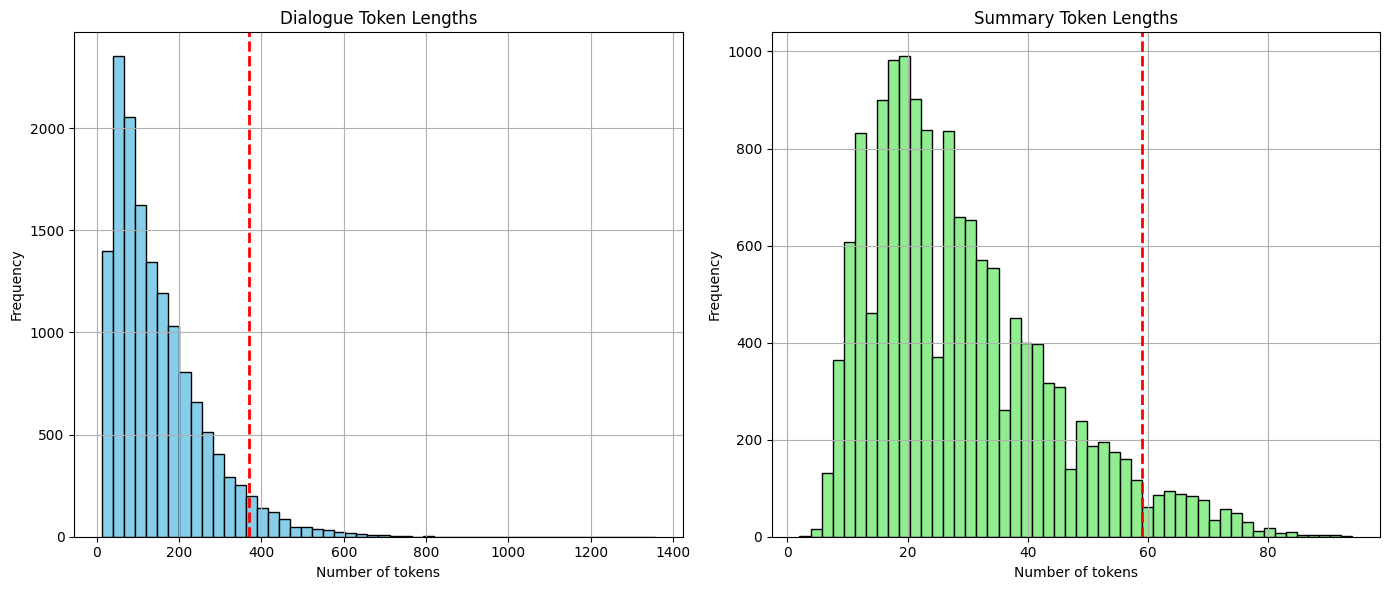

In [17]:
import matplotlib.pyplot as plt

dialogue_lengths = train_data["dialogue"].apply(lambda x: len(tokenizer.encode(x, truncation=False)))

summary_lengths = train_data["summary"].apply(lambda x: len(tokenizer.encode(x, truncation=False)))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(dialogue_lengths, bins=50, color='skyblue', edgecolor='black')
plt.axvline(dialogue_lengths.quantile(0.95), color='red', linestyle='dashed', linewidth=2)
plt.title("Dialogue Token Lengths")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(summary_lengths, bins=50, color='lightgreen', edgecolor='black')
plt.axvline(summary_lengths.quantile(0.95), color='red', linestyle='dashed', linewidth=2)
plt.title("Summary Token Lengths")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()


In [18]:
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)


train_dataset = Dataset.from_pandas(train_data)
val_dataset = Dataset.from_pandas(val_data)
test_dataset = Dataset.from_pandas(test_data)

# Tokenizer

In [19]:
def tokenization(examples):

    inputs = ["summarize: " + dialogue for dialogue in examples["dialogue"]]

    model_inputs = tokenizer(
        inputs,
        max_length=int(max_input_len),
        truncation=True,
        padding=False
    )

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            text_target=examples["summary"],
            max_length=int(max_target_len),
            truncation=True,
            padding=False
        )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


In [20]:
tokenized_train = train_dataset.map(tokenization, batched=True)
tokenized_val = val_dataset.map(tokenization, batched=True)

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

# Dynamic Padding Using DataCollator

In [21]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding='longest',        
    max_length=512,
    pad_to_multiple_of=8,     
    label_pad_token_id=-100   
)

# Training Arguments

In [22]:
training_args = TrainingArguments(

    output_dir="./t5_summarizer",
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",


    eval_strategy="steps",
    eval_steps=500,


    num_train_epochs=4,
    learning_rate=3e-4,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,


    fp16=True,                      
    dataloader_num_workers=4,       
    dataloader_pin_memory=True,     


    logging_steps=50,
    report_to="none"
)


# Training

In [23]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_val,

    tokenizer=tokenizer,

    data_collator=data_collator,
    
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2,early_stopping_threshold = 0.0001)]
)

trainer.train()

Step,Training Loss,Validation Loss
500,1.974200,1.780284
1000,1.797500,1.729519
1500,1.758600,1.701893
2000,1.652400,1.688809
2500,1.719500,1.673126
3000,1.577200,1.677261
3500,1.610000,1.665732


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=3684, training_loss=1.7665917544618621, metrics={'train_runtime': 4904.0583, 'train_samples_per_second': 12.015, 'train_steps_per_second': 0.751, 'total_flos': 5410210269364224.0, 'train_loss': 1.7665917544618621, 'epoch': 4.0})

# Save Model & Load Model

In [24]:
model.save_pretrained("models/t5_summarizer_model")
tokenizer.save_pretrained("models/t5_summarizer_model")

('models/t5_summarizer_model\\tokenizer_config.json',
 'models/t5_summarizer_model\\special_tokens_map.json',
 'models/t5_summarizer_model\\spiece.model',
 'models/t5_summarizer_model\\added_tokens.json')

In [25]:
model = T5ForConditionalGeneration.from_pretrained("models/t5_summarizer_model")

tokenizer = T5Tokenizer.from_pretrained("models/t5_summarizer_model")

In [26]:
def summarize_dialogue(dialogue):

    dialogue = Preprocessing_text(dialogue)

    dialogue = "summarize: " + dialogue
    
    
    inputs = tokenizer(dialogue,
                       return_tensors="pt",
                       truncation=True, 
                       padding="max_length", 
                       max_length=int(max_input_len))

    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=int(max_target_len),
        min_length=20,
        num_beams=4,
        length_penalty=2.0,
        do_sample=False,
        no_repeat_ngram_size=3   
    )

    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return summary

In [27]:
from tqdm import tqdm 
tqdm.pandas()  

test_data["predicted_summary"] = test_data["dialogue"].progress_apply(summarize_dialogue)


100%|██████████| 819/819 [23:02<00:00,  1.69s/it]


In [ ]:
for i in range(3):
    print(f"Example {i+1}")
    print("=" * 50)
    print(f"🔹 Dialogue:\n{test_data['dialogue'].iloc[i]}\n")
    print(f"True Summary:\n{test_data['summary'].iloc[i]}\n")
    print(f"Predicted Summary:\n{test_data['predicted_summary'].iloc[i]}")
    print("=" * 50)


Example 1
🔹 Dialogue:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

True Summary:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.

Predicted Summary:
Amanda has Betty's number. She can't find it. Larry called Betty last time they were at the park together. Hannah doesn't know him well. Hannah would rather text Betty.
Example 2
🔹 Dialogue:
Eric: MACHINE!
Rob: That's so gr8!
Eric: I know! And shows how Americans see Russian ;)
Rob: And it's really funny!
Eric: I know! I especially like the train part!
Rob: Hahaha! No one talks to the machine like that!
Eric: Is this his only stand-up?
Rob: Idk. I

# Evaluation Metrics 

In [29]:
rouge = load("rouge")

results = rouge.compute(
    predictions=test_data["predicted_summary"].tolist(),
    references=test_data["summary"].tolist()
)

print("ROUGE Scores:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")    

ROUGE Scores:
rouge1: 0.4618
rouge2: 0.2192
rougeL: 0.3664
rougeLsum: 0.3663
